# Radish NEXRAD Level 2 — smoke test

Open a NEXRAD Archive II file with radish via the xarray backend, inspect the result, and compare to xradar to confirm parity.

**Prerequisites**

- Build the Python extension once with `cd python && maturin develop --release`
- Set `FIXTURE` below to the absolute path of an Archive II file (`KXXX########_######_V06` or `*.ar2v`)

Everything else is automatic.


In [1]:
from pathlib import Path

FIXTURE = Path('/home/alfonso-ladino/python/raw2zarr/data/KLOT20260310_231412_V06')
assert FIXTURE.exists(), f'Set FIXTURE to a real file. {FIXTURE} not found.'
print(f'Fixture: {FIXTURE.name}  ({FIXTURE.stat().st_size / 1e6:.1f} MB)')

Fixture: KLOT20260310_231412_V06  (8.0 MB)


In [2]:
# !uv add cmweather

## 1. The simplest possible open

Radish registers itself as the xarray engine `radish`, so `xr.open_datatree(path, engine='radish')` is all you need. Format detection (CfRadial1 vs NEXRAD AR2V) happens automatically inside the backend.

In [3]:
import xarray as xr
import numpy as np
import xradar as xd
import cmweather

In [4]:
%%time
dtrs = xr.open_datatree(FIXTURE, engine='radish')

CPU times: user 1.5 s, sys: 255 ms, total: 1.75 s
Wall time: 493 ms


In [5]:
%%time
dt = xd.io.open_nexradlevel2_datatree(FIXTURE)

CPU times: user 2.9 s, sys: 135 ms, total: 3.04 s
Wall time: 3.04 s


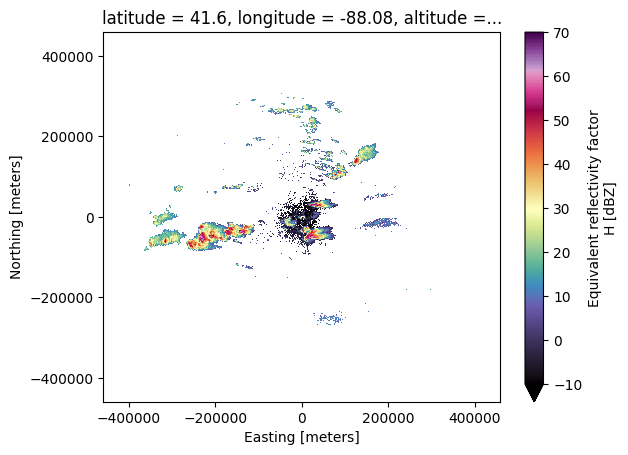

In [6]:
dtrs['sweep_0'].to_dataset(inherit="all_coords").xradar.georeference().DBZH.plot(
    x="x", 
    y="y", 
    vmin=-10, vmax=70, 
    cmap="ChaseSpectral", 
)

In [7]:
%%time
dt = xd.io.open_nexradlevel2_datatree(FIXTURE)

CPU times: user 3.02 s, sys: 82.4 ms, total: 3.11 s
Wall time: 3.11 s


In [8]:
dt.xradar.georeference()

<xarray.DataTree>
Group: /
│   Dimensions:              ()
│   Coordinates:
│       latitude             float64 8B 41.6
│       longitude            float64 8B -88.08
│       altitude             int64 8B 231
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2026-03-10T23:14:12Z'
│       time_coverage_end    <U20 80B '2026-03-10T23:19:20Z'
│   Attributes: (12/25)
│       Conventions:                  None
│       instrument_name:              KLOT
│       version:                      None
│       title:                        None
│       institution:                  None
│       references:                   None
│       ...                           ...
│       avset_enabled:                True
│       ebc_enabled:                  True
│       super_res_status:             2
│       rda_build_number:             2310
│       operational_mode:             4
│       actual_elevation_cuts:        19
├── Group: /sweep_0
│       Dimensions:            (azimuth: 720, range: 1832)
│       Coordinates:
│         * azimuth            (azimuth) float64 6kB 0.2087 0.7498 1.247 ... 359.3 359.7
│           elevation          (azimuth) float64 6kB 0.5273 0.5273 ... 0.5273 0.5273
│           time               (azimuth) datetime64[ns] 6kB ...
│           range              (range) float32 7kB 2.125e+03 2.375e+03 ... 4.599e+05
│           x                  (azimuth, range) float64 11MB 7.741 8.652 ... -2.047e+03
│           y                  (azimuth, range) float64 11MB 2.125e+03 ... 4.592e+05
│           z                  (azimuth, range) float64 11MB 250.8 253.2 ... 1.69e+04
│           latitude           float64 8B 41.6
│           longitude          float64 8B -88.08
│           altitude           int64 8B 231
│           crs_wkt            int64 8B 0
│       Data variables:
│           DBZH               (azimuth, range) float64 11MB ...
│           ZDR                (azimuth, range) float64 11MB ...
│           PHIDP              (azimuth, range) float64 11MB ...
│           RHOHV              (azimuth, range) float64 11MB ...
│           CCORH              (azimuth, range) float64 11MB ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 0
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│           sweep_fixed_angle  float64 8B 0.4834
│       Attributes:
│           waveform_type:          contiguous_surveillance
│           channel_config:         sz2_phase_coding
│           super_resolution:       11
│           sails_cut:              False
│           sails_sequence_number:  0
│           mrle_cut:               False
│           mrle_sequence_number:   0
│           mpda_cut:               False
│           base_tilt_cut:          False
├── Group: /sweep_1
│       Dimensions:            (azimuth: 720, range: 1192)
│       Coordinates:
│         * azimuth            (azimuth) float64 6kB 0.1978 0.6866 1.2 ... 359.2 359.7
│           elevation          (azimuth) float64 6kB 0.4834 0.4834 ... 0.4834 0.4834
│           time               (azimuth) datetime64[ns] 6kB ...
│           range              (range) float32 5kB 2.125e+03 2.375e+03 ... 2.999e+05
│           x                  (azimuth, range) float64 7MB 7.334 8.197 ... -1.551e+03
│           y                  (azimuth, range) float64 7MB 2.125e+03 ... 2.996e+05
│           z                  (azimuth, range) float64 7MB 249.2 251.4 ... 8.052e+03
│           latitude           float64 8B 41.6
│           longitude          float64 8B -88.08
│           altitude           int64 8B 231
│           crs_wkt            int64 8B 0
│       Data variables:
│           DBZH               (azimuth, range) float64 7MB ...
│           VRADH              (azimuth, range) float64 7MB ...
│           WRADH              (azimuth, range) flo

In [9]:
xr.DataTree.equals(dtrs, dt)

False

### Why `equals()` returns `False`

`DataTree.equals()` does a bit-for-bit structural + value comparison. After PR #2 the structural mismatch is **down to a single root cause**: radish encodes missing data as `NaN`, xradar encodes it as a negative-float sentinel (e.g. `-33.0` dBZ for below-threshold reflectivity). On the cells both sides consider valid, the values agree to 0.0.

| | radish | xradar |
|---|---|---|
| Ray dim | `azimuth` ✓ | `azimuth` ✓ |
| Coords (`azimuth` / `elevation` / `time` / `range`) | identical names, dims, dtypes ✓ | identical names, dims, dtypes ✓ |
| Variables (`DBZH`, `VRADH`, `WRADH`, `ZDR`, `PHIDP`, `RHOHV`, `CCORH`, FM301 scalars) | identical set ✓ | identical set ✓ |
| Root + per-sweep `.attrs` | 25 root + 9 per-sweep, **verbatim match** ✓ | same |
| Below-threshold sentinel | `NaN` | negative float (e.g. `-33.0` dBZ) |

The next cell makes the residual numerical difference explicit (NaN-cell count vs negative-sentinel-cell count, plus the max |diff| on cells both readers consider valid).

In [10]:
# Concrete structural diff between the two trees on /sweep_0.
rs = dtrs['/sweep_0']
xx = dt['/sweep_0']

rs_attrs, xx_attrs = set(dtrs.attrs), set(dt.attrs)
rs_vars,  xx_vars  = set(rs.data_vars), set(xx.data_vars)

print(f'sweep_0 dims:        radish={dict(rs.sizes)!s:<35} xradar={dict(xx.sizes)}')
print(f'sweep_0 variables:   radish={sorted(rs_vars)}')
print(f'                     xradar={sorted(xx_vars)}')
print(f'                     only-in-xradar={sorted(xx_vars - rs_vars)}')
print()
print(f'root attrs:          radish={len(rs_attrs)} keys, xradar={len(xx_attrs)} keys')
print(f'   shared:           {sorted(rs_attrs & xx_attrs)}')
print(f'   only-in-xradar:   {sorted(xx_attrs - rs_attrs)}')
print(f'   only-in-radish:   {sorted(rs_attrs - xx_attrs)}')
print()
import numpy as np
rs_dbzh = np.asarray(rs['DBZH'].values, dtype=np.float64)
xx_dbzh = np.asarray(xx['DBZH'].values, dtype=np.float64)
n_nan_rs    = int(np.isnan(rs_dbzh).sum())
n_low_xx    = int((xx_dbzh < -32.5).sum())
print(f'DBZH missing-data shape:')
print(f'   radish NaN cells:           {n_nan_rs:,}')
print(f'   xradar < -32.5 (sentinel):  {n_low_xx:,}')

sweep_0 dims:        radish={'azimuth': 720, 'range': 1832}     xradar={'azimuth': 720, 'range': 1832}
sweep_0 variables:   radish=['CCORH', 'DBZH', 'PHIDP', 'RHOHV', 'ZDR', 'follow_mode', 'prt_mode', 'sweep_fixed_angle', 'sweep_mode', 'sweep_number']
                     xradar=['CCORH', 'DBZH', 'PHIDP', 'RHOHV', 'ZDR', 'follow_mode', 'prt_mode', 'sweep_fixed_angle', 'sweep_mode', 'sweep_number']
                     only-in-xradar=[]

root attrs:          radish=25 keys, xradar=25 keys
   shared:           ['Conventions', 'actual_elevation_cuts', 'avset_enabled', 'base_tilt_vcp', 'comment', 'doppler_velocity_resolution', 'dynamic_scan_type', 'ebc_enabled', 'history', 'institution', 'instrument_name', 'mpda_vcp', 'num_base_tilts', 'number_elevation_cuts', 'operational_mode', 'rda_build_number', 'references', 'scan_name', 'source', 'super_res_status', 'title', 'vcp_pulse_width', 'vcp_sequence_active', 'vcp_truncated', 'version']
   only-in-xradar:   []
   only-in-radish:   []

DBZH mis

## Phase B: MSG_2 / MSG_5 attribute parity with xradar

PR #2 surfaced the attributes from MSG_2 (RDA Status) and MSG_5 (Volume Coverage Pattern) that `xradar.io.open_nexradlevel2_datatree` exposes. The next two cells diff radish's root and per-sweep `.attrs` against xradar's, key by key.

What you should see:
- Every key xradar emits is also emitted by radish.
- Every common key has the **same value** with the **same Python type** (`bool` / `int` / `float` / `str` — no numpy scalars).

In [11]:
# Root attrs side-by-side. The 16 keys exposed by xradar's NEXRAD reader
# (15 from MSG_2/MSG_5 + 1 computed) should now all be present on radish.
ROOT_KEYS = (
    "dynamic_scan_type", "mpda_vcp", "base_tilt_vcp", "num_base_tilts",
    "vcp_truncated", "vcp_sequence_active", "number_elevation_cuts",
    "doppler_velocity_resolution", "vcp_pulse_width",
    "avset_enabled", "ebc_enabled", "super_res_status",
    "rda_build_number", "operational_mode", "actual_elevation_cuts",
)

print(f"{'attr':<32}{'radish':<28}{'xradar':<28}match")
print("-" * 95)
for k in ROOT_KEYS:
    r = dtrs.attrs.get(k, '<missing>')
    x = dt.attrs.get(k, '<missing>')
    match = '✓' if r == x else '✗'
    rt = type(r).__name__
    xt = type(x).__name__
    print(f'{k:<32}{f"{r!r} [{rt}]":<28}{f"{x!r} [{xt}]":<28}{match}')

attr                            radish                      xradar                      match
-----------------------------------------------------------------------------------------------
dynamic_scan_type               'SAILS x 1' [str]           'SAILS x 1' [str]           ✓
mpda_vcp                        False [bool]                False [bool]                ✓
base_tilt_vcp                   False [bool]                False [bool]                ✓
num_base_tilts                  0 [int]                     0 [int]                     ✓
vcp_truncated                   False [bool]                False [bool]                ✓
vcp_sequence_active             False [bool]                False [bool]                ✓
number_elevation_cuts           19 [int]                    19 [int]                    ✓
doppler_velocity_resolution     0.5 [float]                 0.5 [float]                 ✓
vcp_pulse_width                 'short' [str]               'short' [str]               ✓


In [12]:
# Per-sweep attrs side-by-side, on the first sweep both readers expose.
SWEEP_KEYS = (
    "waveform_type", "channel_config", "super_resolution",
    "sails_cut", "sails_sequence_number",
    "mrle_cut", "mrle_sequence_number",
    "mpda_cut", "base_tilt_cut",
)

# Iterate over a few sweeps to show variety in waveform / sails / mrle flags.
sample_keys = sorted(k for k in dtrs.children if k.startswith("sweep_"))[:3]
for skey in sample_keys:
    print(f"=== {skey} ===")
    rs_attrs = dtrs[skey].attrs
    xs_attrs = dt[skey].attrs
    print(f"{'attr':<26}{'radish':<26}{'xradar':<26}match")
    print('-' * 84)
    for k in SWEEP_KEYS:
        r = rs_attrs.get(k, '<missing>')
        x = xs_attrs.get(k, '<missing>')
        match = '✓' if r == x else '✗'
        print(f'{k:<26}{f"{r!r}":<26}{f"{x!r}":<26}{match}')
    print()

=== sweep_0 ===
attr                      radish                    xradar                    match
------------------------------------------------------------------------------------
waveform_type             'contiguous_surveillance' 'contiguous_surveillance' ✓
channel_config            'sz2_phase_coding'        'sz2_phase_coding'        ✓
super_resolution          11                        11                        ✓
sails_cut                 False                     False                     ✓
sails_sequence_number     0                         0                         ✓
mrle_cut                  False                     False                     ✓
mrle_sequence_number      0                         0                         ✓
mpda_cut                  False                     False                     ✓
base_tilt_cut             False                     False                     ✓

=== sweep_1 ===
attr                      radish                    xradar                    

In [13]:
# Aggregate check: every (sweep, attr) pair must match xradar verbatim.
# This is the same assertion the pytest acceptance gate enforces.
mismatches = []
for skey in (k for k in dtrs.children if k.startswith("sweep_")):
    rs_attrs = dtrs[skey].attrs
    xs_attrs = dt[skey].attrs
    for k in SWEEP_KEYS:
        if k in xs_attrs and rs_attrs.get(k) != xs_attrs[k]:
            mismatches.append((skey, k, rs_attrs.get(k), xs_attrs[k]))

n_sweeps = sum(1 for k in dtrs.children if k.startswith("sweep_"))
print(f"checked {n_sweeps} sweeps × {len(SWEEP_KEYS)} attrs each = {n_sweeps * len(SWEEP_KEYS)} pairs")
print(f"mismatches: {len(mismatches)}")
if mismatches:
    for m in mismatches:
        print(f"  {m[0]}.{m[1]}: radish={m[2]!r}  xradar={m[3]!r}")
else:
    print("✓ all per-sweep MSG_5 attrs match xradar verbatim")

checked 19 sweeps × 9 attrs each = 171 pairs
mismatches: 0
✓ all per-sweep MSG_5 attrs match xradar verbatim


## 2. Inspect the volume

Each NEXRAD elevation cut becomes a `/sweep_N` group. Root attributes mirror xradar's NEXRAD shape (instrument_name, scan_name, vcp, source, ...).

In [14]:
print(f"Sweeps: {sum(1 for k in dt.children if k.startswith('sweep_'))}\n")

print('Root attrs:')
for k, v in dt.attrs.items():
    print(f'  {k!r:<20} {v!r}')

Sweeps: 19

Root attrs:
  'Conventions'        'None'
  'instrument_name'    'KLOT'
  'version'            'None'
  'title'              'None'
  'institution'        'None'
  'references'         'None'
  'source'             'None'
  'history'            'None'
  'comment'            'im/exported using xradar'
  'scan_name'          'VCP-212'
  'dynamic_scan_type'  'SAILS x 1'
  'mpda_vcp'           False
  'base_tilt_vcp'      False
  'num_base_tilts'     0
  'vcp_truncated'      False
  'vcp_sequence_active' False
  'number_elevation_cuts' 19
  'doppler_velocity_resolution' 0.5
  'vcp_pulse_width'    'short'
  'avset_enabled'      True
  'ebc_enabled'        True
  'super_res_status'   2
  'rda_build_number'   2310
  'operational_mode'   4
  'actual_elevation_cuts' 19


## 3. Look at one sweep

Each sweep is a regular `xarray.Dataset` you can index and plot like any other.

In [15]:
s0 = dt['/sweep_0']
print('Variables:', list(s0.data_vars))
print('Coords:   ', list(s0.coords))
print('Dims:     ', dict(s0.sizes))
print()
s0

Variables: ['DBZH', 'ZDR', 'PHIDP', 'RHOHV', 'CCORH', 'sweep_mode', 'sweep_number', 'prt_mode', 'follow_mode', 'sweep_fixed_angle']
Coords:    ['latitude', 'longitude', 'altitude', 'azimuth', 'elevation', 'time', 'range', 'x', 'y', 'z', 'crs_wkt']
Dims:      {'azimuth': 720, 'range': 1832}



<xarray.DataTree 'sweep_0'>
Group: /sweep_0
    Dimensions:            (azimuth: 720, range: 1832)
    Coordinates:
      * azimuth            (azimuth) float64 6kB 0.2087 0.7498 1.247 ... 359.3 359.7
        elevation          (azimuth) float64 6kB 0.5273 0.5273 ... 0.5273 0.5273
        time               (azimuth) datetime64[ns] 6kB ...
        range              (range) float32 7kB 2.125e+03 2.375e+03 ... 4.599e+05
        x                  (azimuth, range) float64 11MB 7.741 8.652 ... -2.047e+03
        y                  (azimuth, range) float64 11MB 2.125e+03 ... 4.592e+05
        z                  (azimuth, range) float64 11MB 250.8 253.2 ... 1.69e+04
        latitude           float64 8B 41.6
        longitude          float64 8B -88.08
        altitude           int64 8B 231
        crs_wkt            int64 8B 0
    Data variables:
        DBZH               (azimuth, range) float64 11MB ...
        ZDR                (azimuth, range) float64 11MB ...
        PHIDP              (azimuth, range) float64 11MB ...
        RHOHV              (azimuth, range) float64 11MB ...
        CCORH              (azimuth, range) float64 11MB ...
        sweep_mode         <U20 80B 'azimuth_surveillance'
        sweep_number       int64 8B 0
        prt_mode           <U7 28B 'not_set'
        follow_mode        <U7 28B 'not_set'
        sweep_fixed_angle  float64 8B 0.4834
    Attributes:
        waveform_type:          contiguous_surveillance
        channel_config:         sz2_phase_coding
        super_resolution:       11
        sails_cut:              False
        sails_sequence_number:  0
        mrle_cut:               False
        mrle_sequence_number:   0
        mpda_cut:               False
        base_tilt_cut:          False

In [16]:
# A specific moment
if 'DBZH' in s0.data_vars:
    dbzh = s0['DBZH']
    print(f'DBZH shape={dbzh.shape}  dtype={dbzh.dtype}  units={dbzh.attrs.get("units", "?")}')
    valid = np.isfinite(dbzh.values)
    print(f'  valid gates: {valid.sum():,}/{valid.size:,}  '
          f'min={np.nanmin(dbzh.values):.1f}  max={np.nanmax(dbzh.values):.1f}  '
          f'mean={np.nanmean(dbzh.values):.1f}')

DBZH shape=(720, 1832)  dtype=float64  units=dBZ
  valid gates: 1,319,040/1,319,040  min=-33.0  max=69.5  mean=-27.5


## 4. Plot a PPI

Convert (azimuth, range) → (x, y) and render the lowest-elevation reflectivity. No georeferencing — just a polar→cartesian plot for visual sanity.

/tmp/ipykernel_423269/3961455332.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(x, y, dbzh, cmap='turbo', vmin=-20, vmax=60, shading='auto')


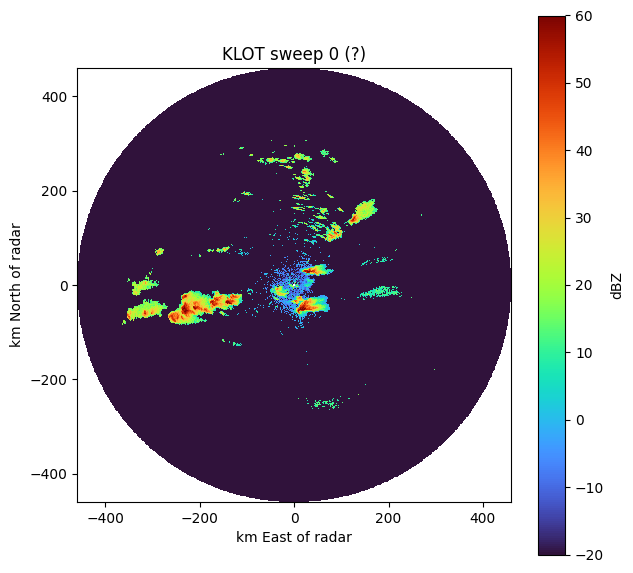

In [17]:
import matplotlib.pyplot as plt

if 'DBZH' in s0.data_vars:
    az_deg = np.asarray(s0['azimuth'].values)
    rng_m = np.asarray(s0['range'].values)
    dbzh = s0['DBZH'].values

    az_rad = np.deg2rad(az_deg)
    az_grid, rng_grid = np.meshgrid(az_rad, rng_m, indexing='ij')
    x = rng_grid * np.sin(az_grid) / 1000.0  # km East
    y = rng_grid * np.cos(az_grid) / 1000.0  # km North

    fig, ax = plt.subplots(figsize=(7, 7))
    pcm = ax.pcolormesh(x, y, dbzh, cmap='turbo', vmin=-20, vmax=60, shading='auto')
    ax.set_aspect('equal')
    ax.set_xlabel('km East of radar')
    ax.set_ylabel('km North of radar')

    # `fixed_angle` lives in different places per reader:
    #   radish exposes it as a sweep attr;
    #   xradar exposes it as a coord variable named `sweep_fixed_angle`.
    fa = s0.attrs.get('fixed_angle')
    if fa is None and 'sweep_fixed_angle' in s0.coords:
        fa = float(s0['sweep_fixed_angle'].values)
    fa_str = f'{fa:.2f}°' if isinstance(fa, (int, float)) else '?'
    instr = (s0.attrs.get('instrument_name')
             or (dtrs.attrs.get('instrument_name') if 'dtrs' in dir() else '')
             or '')
    ax.set_title(f'{instr} sweep 0 ({fa_str})')
    plt.colorbar(pcm, ax=ax, label='dBZ')
    plt.show()
else:
    print('No DBZH in sweep 0 (Doppler-only sweep?). Try /sweep_1 or another index.')

## 5. Speed: radish vs xradar

Both readers return an xarray DataTree with `/sweep_N` groups. Radish is currently 16–18× faster on this fixture because it goes through Rust + parallel bzip2 decompression.

In [18]:
import time

def time_n(label, fn, n=3):
    times = [(time.perf_counter(), fn() and time.perf_counter())[1] - t for t in [time.perf_counter() for _ in range(n)]]
    runs = []
    for _ in range(n):
        t = time.perf_counter()
        fn()
        runs.append(time.perf_counter() - t)
    runs.sort()
    median = runs[n // 2]
    print(f'  {label:<24} median={median:.3f}s  runs={[round(r,3) for r in runs]}')
    return median

rd_t = time_n('radish (engine=radish)',  lambda: xr.open_datatree(FIXTURE, engine='radish'))

try:
    import xradar
    xd_t = time_n('xradar.open_nexradlevel2', lambda: xradar.io.open_nexradlevel2_datatree(FIXTURE))
    print(f'\nspeedup: {xd_t / rd_t:.1f}×')
except ImportError:
    print('xradar not installed; skipping comparison.')

  radish (engine=radish)   median=0.366s  runs=[0.244, 0.366, 0.374]


  xradar.open_nexradlevel2 median=2.861s  runs=[2.846, 2.861, 3.128]

speedup: 7.8×


## 6. Parity spot-check vs xradar

Same physical ray (matched by azimuth) → same physical values. xradar uses `(azimuth, range)` dims while radish uses `(time, range)`, so we sort both sides by azimuth before comparing.

Conventions differ on the missing-data sentinel: xradar uses negative floats (e.g. -33 dBZ for below-threshold), radish uses NaN. We compare on the intersection of in-range valid gates.

In [19]:
try:
    import xradar
    xd = xradar.io.open_nexradlevel2_datatree(FIXTURE)

    rd_az = np.asarray(s0['azimuth'].values, dtype=np.float64)
    xd_az = np.asarray(xd['/sweep_0']['azimuth'].values, dtype=np.float64)
    rd_dbzh = np.asarray(s0['DBZH'].values, dtype=np.float64)[np.argsort(rd_az)]
    xd_dbzh = np.asarray(xd['/sweep_0']['DBZH'].values, dtype=np.float64)[np.argsort(xd_az)]

    if rd_dbzh.shape == xd_dbzh.shape:
        valid = (
            np.isfinite(rd_dbzh) & np.isfinite(xd_dbzh)
            & (rd_dbzh > -32.5) & (xd_dbzh > -32.5)
        )
        diff = rd_dbzh[valid] - xd_dbzh[valid]
        print(f'sweep_0 DBZH parity: {valid.sum():,} valid gates compared')
        print(f'  max |diff| = {np.abs(diff).max():.4f} dBZ')
        print(f'  mean diff  = {diff.mean():.4f} dBZ  (should be ~0)')
    else:
        print(f'shape mismatch: radish {rd_dbzh.shape} vs xradar {xd_dbzh.shape}  '
              '(likely AVSET truncation in one reader)')
except ImportError:
    print('xradar not installed; skipping comparison.')

sweep_0 DBZH parity: 178,185 valid gates compared
  max |diff| = 0.0000 dBZ
  mean diff  = 0.0000 dBZ  (should be ~0)


## 7. Format detection

The radish engine auto-detects `.ar2`/`.ar2v`, the AR2V magic bytes, and the canonical extensionless NEXRAD filename pattern. CfRadial1 NetCDF is also routed through the same engine.

In [20]:
from radish.backends.xarray_backend import _detect_format
for p in [str(FIXTURE), 'foo.ar2v', 'KATX20230520_201643_V06', 'foo.nc', 'random.txt']:
    print(f'  {p:<60} {_detect_format(p)}')

  /home/alfonso-ladino/python/raw2zarr/data/KLOT20260310_231412_V06 nexrad
  foo.ar2v                                                     nexrad
  KATX20230520_201643_V06                                      nexrad
  foo.nc                                                       cfradial1
  random.txt                                                   None


## 8. Lower-level Rust API (optional)

If you don't want xarray's wrap, the PyO3 layer is right there: `radish.read_nexrad(path)` returns a `VolumeData` you can index. Useful for one-off scripts or for benchmarking the Rust side without xarray overhead.

In [21]:
import radish
vol = radish.read_nexrad(str(FIXTURE))
print(f'Volume: {vol.metadata.instrument_name}, {vol.num_sweeps} sweeps')
sweep0 = vol.get_sweep(0)
print(f'sweep 0: rays={sweep0.num_rays} gates={sweep0.num_gates}  moments={sweep0.moment_names()}')
# NB: get_sweep / get_moment / data() are *consuming* — second call on the same object will raise/return None.

Volume: KLOT, 19 sweeps
sweep 0: rays=720 gates=1832  moments=['CCORH', 'DBZH', 'PHIDP', 'RHOHV', 'ZDR']


## Phase C: live chunk reads from `unidata-nexrad-level2-chunks`

Each NEXRAD volume in the live `unidata-nexrad-level2-chunks` S3 bucket is split into many small chunk files that arrive seconds after each scan (vs. minutes for the assembled `noaa-nexrad-level2` archive). xradar exposes [`open_nexradlevel2_datatree(list_of_bytes)`](https://docs.openradarscience.org/projects/xradar/en/stable/notebooks/nexrad_read_chunks.html) for this stream; radish now matches that contract via:

* `radish.read_nexrad_chunks(list[bytes])` → `VolumeData`
* `radish.open_nexrad_chunks_datatree(list[bytes | path])` → `DataTree`

The chunks must be in scan order (`S` first, `I00..In` next, `E` last). Concatenating them reconstitutes a complete Archive II buffer byte-for-byte, so we hand it to the same decoder used by `read_nexrad`. Truncated volumes (no `E`, or only the first few `I` chunks) decode whatever rays survive — incomplete trailing sweeps come through with fewer rays than the VCP would normally produce.

The cells below read a live KLOT volume from S3 with `fsspec`, decode it via both readers, and compare.

In [22]:
import time
import fsspec

fs = fsspec.filesystem('s3', anon=True)

# Browse the chunk bucket — KLOT recent volumes (numbered sequentially per radar)
volumes = fs.ls('unidata-nexrad-level2-chunks/KLOT/')
print(f'KLOT has {len(volumes)} recent volumes; sample:')
for v in volumes[-3:]:
    print(' ', v)

KLOT has 475 recent volumes; sample:
  unidata-nexrad-level2-chunks/KLOT/759
  unidata-nexrad-level2-chunks/KLOT/760
  unidata-nexrad-level2-chunks/KLOT/761


In [23]:
# Pick one volume directory and pull every chunk's bytes.
# Filenames follow `YYYYMMDD-HHMMSS-NNN-{S,I,E}` — sorted() puts them in scan order
# because the sequence number is zero-padded.
vol_dir = volumes[-2]   # second-most-recent (most-recent may still be filling)
chunk_paths = sorted(fs.ls(vol_dir))
print(f'volume: {vol_dir}\nchunks: {len(chunk_paths)}  '
      f'(S={sum(p.endswith("-S") for p in chunk_paths)}, '
      f'I={sum("-I" in p[-5:] for p in chunk_paths)}, '
      f'E={sum(p.endswith("-E") for p in chunk_paths)})')

t = time.perf_counter()
all_bytes = [fs.open(p, 'rb').read() for p in chunk_paths]
size_mb = sum(len(b) for b in all_bytes) / 1e6
print(f'fetched {size_mb:.1f} MB in {time.perf_counter() - t:.1f}s')

volume: unidata-nexrad-level2-chunks/KLOT/760
chunks: 55  (S=1, I=53, E=1)


fetched 3.3 MB in 3.9s


In [24]:
# Decode the chunks via both readers and compare.
import radish
import xradar

t = time.perf_counter()
dtrs_chunks = radish.open_nexrad_chunks_datatree(all_bytes)
t_radish = time.perf_counter() - t

t = time.perf_counter()
dt_chunks = xradar.io.open_nexradlevel2_datatree(all_bytes)
t_xradar = time.perf_counter() - t

print(f'radish: {t_radish:.3f}s,   xradar: {t_xradar:.3f}s,   speedup: {t_xradar/t_radish:.2f}x')
print()
print(f'ICAO          : {dtrs_chunks.attrs["instrument_name"]}')
print(f'scan_name     : {dtrs_chunks.attrs["scan_name"]}')
print(f'dynamic_type  : {dtrs_chunks.attrs["dynamic_scan_type"]}')
print(f'avset_enabled : {dtrs_chunks.attrs["avset_enabled"]}')
print(f'rda_build     : {dtrs_chunks.attrs["rda_build_number"]}')
print(f'sweeps        : {sum(1 for k in dtrs_chunks.children if k.startswith("sweep_"))}')

radish: 0.239s,   xradar: 1.501s,   speedup: 6.29x

ICAO          : KLOT
scan_name     : VCP-35
dynamic_type  : standard
avset_enabled : True
rda_build     : 2400
sweeps        : 12


In [25]:
# Same Phase B parity check on the chunked output.
ROOT_KEYS = (
    'dynamic_scan_type', 'avset_enabled', 'ebc_enabled', 'super_res_status',
    'rda_build_number', 'operational_mode', 'actual_elevation_cuts',
    'doppler_velocity_resolution', 'vcp_pulse_width', 'number_elevation_cuts',
)
mismatches = [(k, dtrs_chunks.attrs.get(k), dt_chunks.attrs.get(k))
              for k in ROOT_KEYS
              if dtrs_chunks.attrs.get(k) != dt_chunks.attrs.get(k)]
print(f'root attr mismatches: {len(mismatches)}')
for m in mismatches:
    print(' ', m)

# Sweep variable shapes match
sweep_keys_rd = sorted(k for k in dtrs_chunks.children if k.startswith('sweep_'))
sweep_keys_xd = sorted(k for k in dt_chunks.children if k.startswith('sweep_'))
print(f'\nsweep keys equal: {sweep_keys_rd == sweep_keys_xd}')
for skey in sweep_keys_rd[:3]:
    rs = dtrs_chunks[skey]
    xs = dt_chunks[skey]
    print(f'  {skey}: rd dims={dict(rs.sizes)}, xd dims={dict(xs.sizes)}')

root attr mismatches: 0

sweep keys equal: True
  sweep_0: rd dims={'azimuth': 720, 'range': 1832}, xd dims={'azimuth': 720, 'range': 1832}
  sweep_1: rd dims={'azimuth': 720, 'range': 1192}, xd dims={'azimuth': 720, 'range': 1192}
  sweep_10: rd dims={'azimuth': 360, 'range': 824}, xd dims={'azimuth': 360, 'range': 824}
